# Project 7B — Multi-Asset Momentum Backtester

## Objective
Build a cross-sectional momentum strategy across 10 Nifty 50 stocks.
Each day buy the top 3 momentum stocks and compare against Nifty 50 benchmark.

## Universe
10 large-cap Nifty 50 stocks across banking, IT, FMCG and finance:
RELIANCE, TCS, HDFCBANK, INFY, ICICIBANK, HINDUNILVR, ITC, SBIN, BAJFINANCE, AXISBANK

## Strategy Logic
- Momentum signal = 20-day return for each stock
- Rank all 10 stocks by momentum daily
- Buy top 3 stocks with equal weight (33.3% each)
- Rebalance daily — signal from yesterday, trade today
- Transaction cost = 0.1% per stock change

## Results
| Metric | Portfolio | Nifty 50 |
|--------|-----------|----------|
| Total Return | 90.63% | 96.67% |
| Annualised Return | 11.81% | 12.41% |
| Annualised Volatility | 22.53% | 18.32% |
| Sharpe Ratio | 0.342 | 0.404 |
| Max Drawdown | -34.61% | -38.44% |

## Key Findings
- Multi-asset momentum underperforms Nifty on risk-adjusted basis
- Higher volatility (22.5% vs 18.3%) not rewarded with proportionally higher returns
- Strategy significantly outperforms post-2021 bull market visually
- Concentration in 3 stocks creates higher individual drawdowns than 7A
- Contrast with 7A — single asset momentum better for capital protection
- Real improvement would require more stocks, sector constraints, better weighting

## Comparison with Project 7A
Project 7A (single asset) achieved higher Sharpe than benchmark by stepping
out of market during downturns. Project 7B stays invested but rotates stocks —
better in bull markets, worse in crashes. Combined approach would be optimal.

## Libraries
pandas, numpy, matplotlib, yfinance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
# Define tickers
tickers = {
    'RELIANCE':  'RELIANCE.NS',
    'TCS':       'TCS.NS',
    'HDFCBANK':  'HDFCBANK.NS',
    'INFY':      'INFY.NS',
    'ICICIBANK': 'ICICIBANK.NS',
    'HINDUNILVR':'HINDUNILVR.NS',
    'ITC':       'ITC.NS',
    'SBIN':      'SBIN.NS',
    'BAJFINANCE':'BAJFINANCE.NS',
    'AXISBANK':  'AXISBANK.NS'
}

# Download all tickers
price_data = {}

for name, symbol in tickers.items():
    ticker = yf.Ticker(symbol)
    df = ticker.history(start="2018-01-01", end="2024-01-01")
    price_data[name] = df['Close']
    print(f"Downloaded {name}: {len(df)} days")

# Combine into single dataframe
prices = pd.DataFrame(price_data)

# Drop rows where any stock has missing data
prices = prices.dropna()

print(f"\nFinal price matrix shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nFirst 3 rows:")
print(prices.head(3))

Downloaded RELIANCE: 1481 days
Downloaded TCS: 1481 days
Downloaded HDFCBANK: 1481 days
Downloaded INFY: 1481 days
Downloaded ICICIBANK: 1481 days
Downloaded HINDUNILVR: 1481 days
Downloaded ITC: 1481 days
Downloaded SBIN: 1481 days
Downloaded BAJFINANCE: 1481 days
Downloaded AXISBANK: 1481 days

Final price matrix shape: (1481, 10)
Date range: 2018-01-01 to 2023-12-29

First 3 rows:
                             RELIANCE          TCS    HDFCBANK        INFY  \
Date                                                                         
2018-01-01 00:00:00+05:30  401.864838  1083.771729  432.689056  415.244232   
2018-01-02 00:00:00+05:30  402.483215  1077.872559  436.853760  413.697418   
2018-01-03 00:00:00+05:30  404.095551  1080.924316  432.257385  410.322601   

                            ICICIBANK   HINDUNILVR         ITC        SBIN  \
Date                                                                         
2018-01-01 00:00:00+05:30  298.055054  1184.235229  183.645355  28

In [4]:
# Daily returns for all stocks
returns = prices.pct_change()

# Momentum = 20 day return for all stocks
lookback = 20
momentum = prices.pct_change(lookback)

# Drop ALL NaN rows from both
returns = returns.dropna()
momentum = momentum.dropna()

# Align both to same dates
common_dates = returns.index.intersection(momentum.index)
returns = returns.loc[common_dates]
momentum = momentum.loc[common_dates]

print(f"Returns matrix shape: {returns.shape}")
print(f"Momentum matrix shape: {momentum.shape}")
print(f"\nSample momentum values (first row):")
print(momentum.iloc[0].sort_values(ascending=False))

Returns matrix shape: (1461, 10)
Momentum matrix shape: (1461, 10)

Sample momentum values (first row):
TCS           0.194559
ICICIBANK     0.138414
INFY          0.132650
HDFCBANK      0.076031
AXISBANK      0.049956
ITC           0.049180
RELIANCE      0.044683
HINDUNILVR    0.041465
SBIN          0.021003
BAJFINANCE   -0.027381
Name: 2018-01-30 00:00:00+05:30, dtype: float64


In [5]:
# Parameters
top_n = 3          # buy top 3 momentum stocks
transaction_cost = 0.001  # 0.1% per trade

# Store daily portfolio returns
portfolio_returns = []
dates = []

# Store positions for analysis
position_history = []

# Loop through each day
for i in range(1, len(momentum)):
    
    # Yesterday's momentum → today's positions (no lookahead bias)
    yesterdays_momentum = momentum.iloc[i-1]
    
    # Rank stocks by momentum — top 3 are buys
    ranked = yesterdays_momentum.rank(ascending=False)
    long_stocks = ranked[ranked <= top_n].index.tolist()
    
    # Today's returns for selected stocks
    todays_returns = returns.iloc[i]
    
    # Equal weight across top 3 stocks
    weight = 1.0 / top_n
    
    # Portfolio return today = average return of top 3 stocks
    portfolio_return = todays_returns[long_stocks].mean()
    
    # Transaction cost — simplified: charge on days stocks change
    if i > 1:
        prev_ranked = momentum.iloc[i-2].rank(ascending=False)
        prev_long = prev_ranked[prev_ranked <= top_n].index.tolist()
        # Count how many stocks changed
        changes = len(set(long_stocks) - set(prev_long))
        portfolio_return -= changes * weight * transaction_cost
    
    portfolio_returns.append(portfolio_return)
    dates.append(returns.index[i])
    position_history.append(long_stocks)

# Build results dataframe
results = pd.DataFrame({
    'Portfolio_Returns': portfolio_returns
}, index=dates)

# Nifty 50 benchmark
nifty = yf.Ticker("^NSEI")
nifty_df = nifty.history(start="2018-01-01", end="2024-01-01")
nifty_returns = nifty_df['Close'].pct_change().dropna()
nifty_returns = nifty_returns.loc[nifty_returns.index.isin(results.index)]
results['Nifty_Returns'] = nifty_returns

results = results.dropna()

# Cumulative returns
results['Portfolio_Cumulative'] = (1 + results['Portfolio_Returns']).cumprod()
results['Nifty_Cumulative'] = (1 + results['Nifty_Returns']).cumprod()

print(f"Backtest period: {results.index[0].date()} to {results.index[-1].date()}")
print(f"Trading days: {len(results)}")
print(f"\nFinal cumulative returns:")
print(f"Multi-Asset Momentum: {(results['Portfolio_Cumulative'].iloc[-1]-1)*100:.2f}%")
print(f"Nifty 50 Benchmark:   {(results['Nifty_Cumulative'].iloc[-1]-1)*100:.2f}%")

Backtest period: 2018-01-31 to 2023-12-29
Trading days: 1457

Final cumulative returns:
Multi-Asset Momentum: 90.63%
Nifty 50 Benchmark:   96.67%


In [6]:
risk_free_daily = 0.06 / 252

# ── Sharpe Ratio ──────────────────────────────────────────
port_excess   = results['Portfolio_Returns'] - risk_free_daily
nifty_excess  = results['Nifty_Returns']     - risk_free_daily

sharpe_port  = (port_excess.mean()  / port_excess.std())  * np.sqrt(252)
sharpe_nifty = (nifty_excess.mean() / nifty_excess.std()) * np.sqrt(252)

# ── Max Drawdown ───────────────────────────────────────────
def max_drawdown(cumulative):
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

mdd_port  = max_drawdown(results['Portfolio_Cumulative'])
mdd_nifty = max_drawdown(results['Nifty_Cumulative'])

# ── Annualised Return ──────────────────────────────────────
n_years = len(results) / 252

ann_port  = results['Portfolio_Cumulative'].iloc[-1] ** (1/n_years) - 1
ann_nifty = results['Nifty_Cumulative'].iloc[-1]     ** (1/n_years) - 1

# ── Volatility ────────────────────────────────────────────
vol_port  = results['Portfolio_Returns'].std()  * np.sqrt(252)
vol_nifty = results['Nifty_Returns'].std() * np.sqrt(252)

# ── Print Report ───────────────────────────────────────────
print("=" * 55)
print("     MULTI-ASSET MOMENTUM PERFORMANCE REPORT")
print("=" * 55)
print(f"\n{'Metric':<32} {'Portfolio':>10} {'Nifty 50':>10}")
print("-" * 55)
print(f"{'Total Return':<32} {results['Portfolio_Cumulative'].iloc[-1]-1:>9.2%} {results['Nifty_Cumulative'].iloc[-1]-1:>9.2%}")
print(f"{'Annualised Return':<32} {ann_port:>9.2%} {ann_nifty:>9.2%}")
print(f"{'Annualised Volatility':<32} {vol_port:>9.2%} {vol_nifty:>9.2%}")
print(f"{'Sharpe Ratio':<32} {sharpe_port:>10.3f} {sharpe_nifty:>10.3f}")
print(f"{'Max Drawdown':<32} {mdd_port:>9.2%} {mdd_nifty:>9.2%}")
print("=" * 55)

     MULTI-ASSET MOMENTUM PERFORMANCE REPORT

Metric                            Portfolio   Nifty 50
-------------------------------------------------------
Total Return                        90.63%    96.67%
Annualised Return                   11.81%    12.41%
Annualised Volatility               22.53%    18.32%
Sharpe Ratio                          0.342      0.404
Max Drawdown                       -34.61%   -38.44%


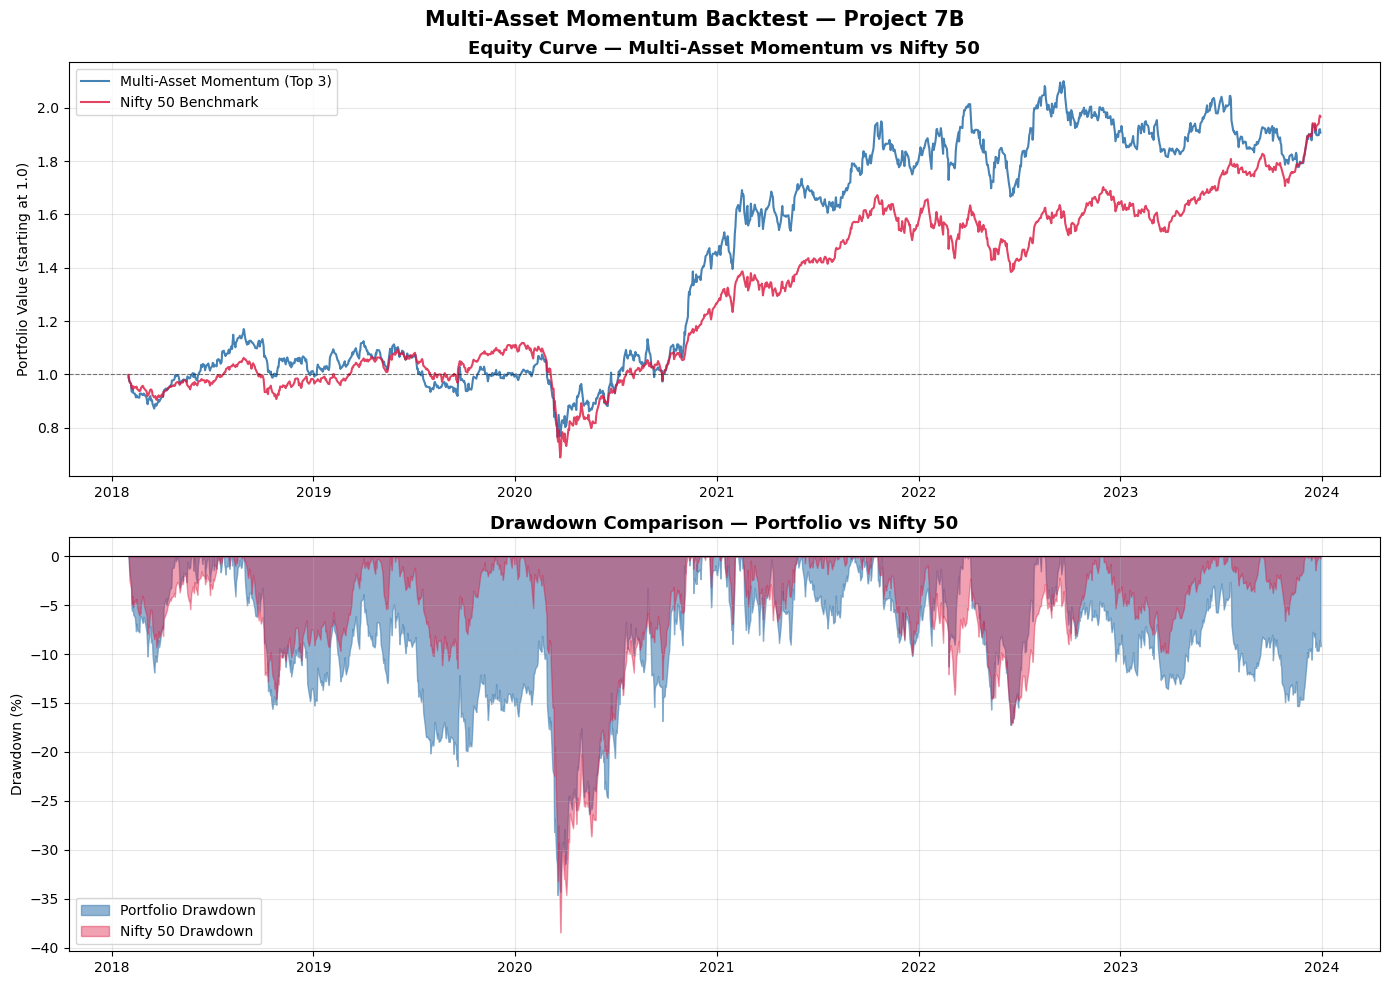

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Plot 1 — Equity Curve ──────────────────────────────────
ax1 = axes[0]
ax1.plot(results.index, results['Portfolio_Cumulative'],
         color='steelblue', linewidth=1.5,
         label='Multi-Asset Momentum (Top 3)')
ax1.plot(results.index, results['Nifty_Cumulative'],
         color='crimson', linewidth=1.5,
         label='Nifty 50 Benchmark', alpha=0.8)
ax1.set_title('Equity Curve — Multi-Asset Momentum vs Nifty 50',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Portfolio Value (starting at 1.0)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Plot 2 — Drawdown ──────────────────────────────────────
def drawdown_series(cumulative):
    rolling_max = cumulative.cummax()
    return (cumulative - rolling_max) / rolling_max

ax2 = axes[1]
ax2.fill_between(results.index,
                 drawdown_series(results['Portfolio_Cumulative']) * 100,
                 alpha=0.6, color='steelblue', label='Portfolio Drawdown')
ax2.fill_between(results.index,
                 drawdown_series(results['Nifty_Cumulative']) * 100,
                 alpha=0.4, color='crimson', label='Nifty 50 Drawdown')
ax2.set_title('Drawdown Comparison — Portfolio vs Nifty 50',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=0.8)

plt.suptitle('Multi-Asset Momentum Backtest — Project 7B',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('multiasset_momentum_results.png', dpi=150, bbox_inches='tight')
plt.show()